1. Импорты и загрузка

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

BASE_DIR = Path.cwd().parent

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

# Загрузка
df = pd.read_excel(BASE_DIR / 'data' / 'base.xlsx', sheet_name='Данные')
df.columns = ['student_id', 'amount', 'course', 'timestamp']
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['date'] = df['timestamp'].dt.date

print(f"Строк: {len(df)}")
print(f"Покупателей: {df['student_id'].nunique()}")
print(f"Курсов: {df['course'].nunique()}")
print(f"Период: {df['timestamp'].min()} — {df['timestamp'].max()}")

Строк: 795
Покупателей: 606
Курсов: 18
Период: 2026-08-04 09:08:31 — 2026-09-10 06:09:12


2. Построение заказов

In [22]:
df['order_id'] = df['student_id'].astype(str) + '_' + df['timestamp'].astype(str)

orders = df.groupby('order_id').agg(
    student_id=('student_id', 'first'),
    timestamp=('timestamp', 'first'),
    revenue=('amount', 'sum'),
    n_courses=('course', 'nunique'),
    courses=('course', lambda x: '; '.join(sorted(set(x))))
).reset_index()

orders['date'] = orders['timestamp'].dt.date

print(f"Заказов: {len(orders)}")
print(f"Средний чек: {orders['revenue'].mean():.2f} ₽")
print(f"Пакетов: {(orders['n_courses'] >= 2).sum()}")
print(f"Повторных покупателей: {(orders.groupby('student_id').size() >= 2).sum()}")


Заказов: 628
Средний чек: 9402.34 ₽
Пакетов: 153
Повторных покупателей: 20


3. Daily metrics

In [23]:
daily_revenue = df.groupby('date').agg(
    revenue=('amount', 'sum'),
    sales=('amount', 'size')
).reset_index()

daily_orders = orders.groupby('date').agg(
    orders=('order_id', 'count'),
    buyers=('student_id', 'nunique'),
    avg_check=('revenue', 'mean')
).reset_index()

daily = daily_revenue.merge(daily_orders, on='date', how='outer').fillna(0)
daily = daily.sort_values('date').reset_index(drop=True)

print(daily.head(10))

         date    revenue  sales  orders  buyers     avg_check
0  2026-08-04   84130.00      9       7       6  12018.571429
1  2026-08-05   67110.00      8       6       6  11185.000000
2  2026-08-06   62445.00      8       7       7   8920.714286
3  2026-08-07   54995.00      6       5       5  10999.000000
4  2026-08-08  275015.00     49      35      35   7857.571429
5  2026-08-09  524091.67     92      68      68   7707.230441
6  2026-08-10  205590.00     36      29      29   7089.310345
7  2026-08-11   96330.00     17      12      12   8027.500000
8  2026-08-12  114930.00     17      14      14   8209.285714
9  2026-08-13   72810.00      9       9       9   8090.000000


4. График: выручка по дням

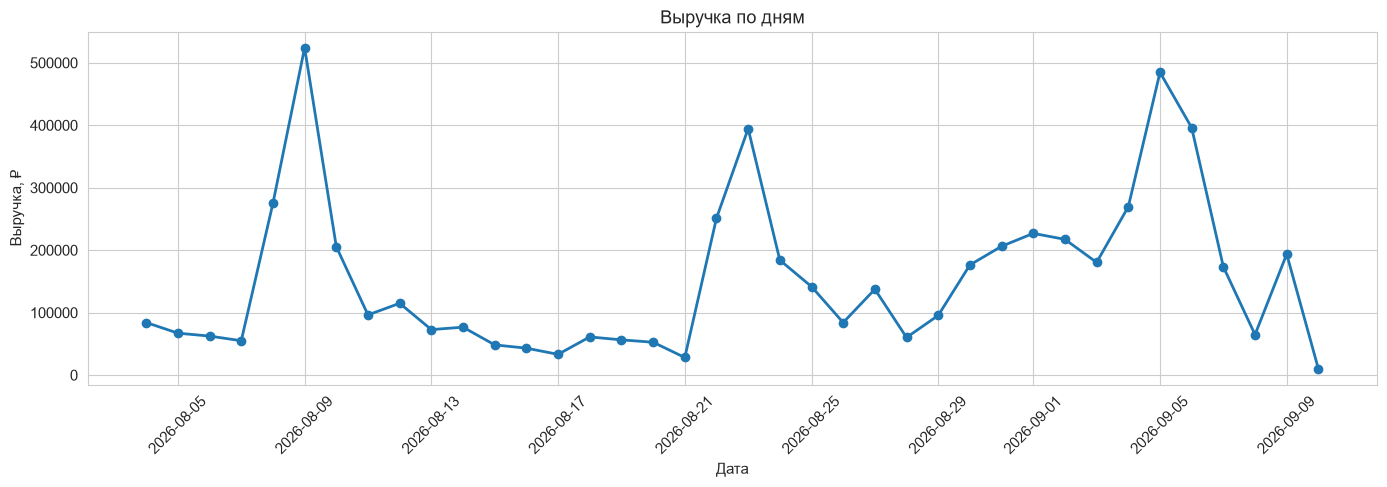

In [24]:
plt.figure(figsize=(14, 5))
plt.plot(daily['date'], daily['revenue'], marker='o', linewidth=2)
plt.title('Выручка по дням')
plt.xlabel('Дата')
plt.ylabel('Выручка, ₽')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

5. График: топ-курсы

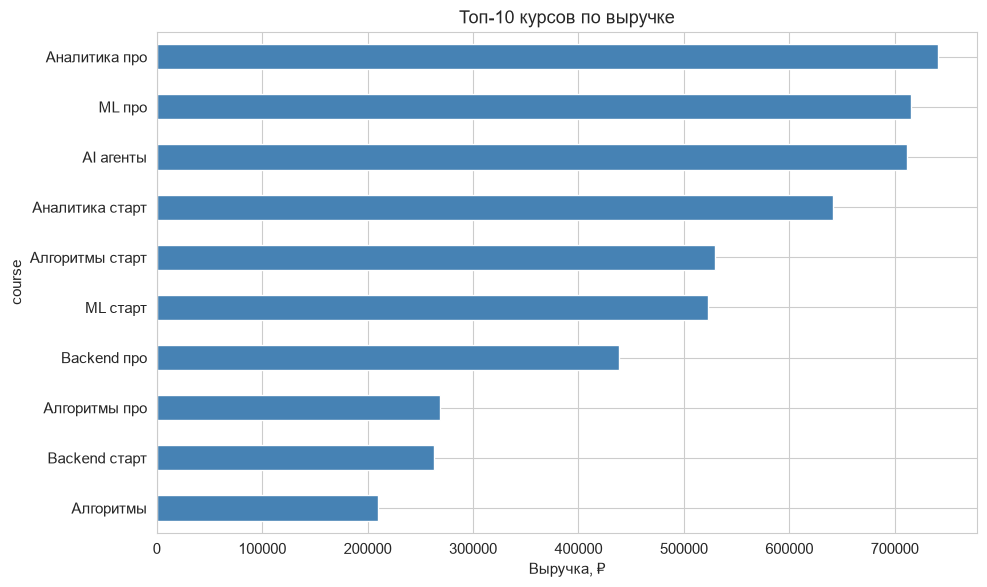

In [25]:
top = df.groupby('course')['amount'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
top.plot(kind='barh', color='steelblue')
plt.title('Топ-10 курсов по выручке')
plt.xlabel('Выручка, ₽')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

6. График: распределение чеков

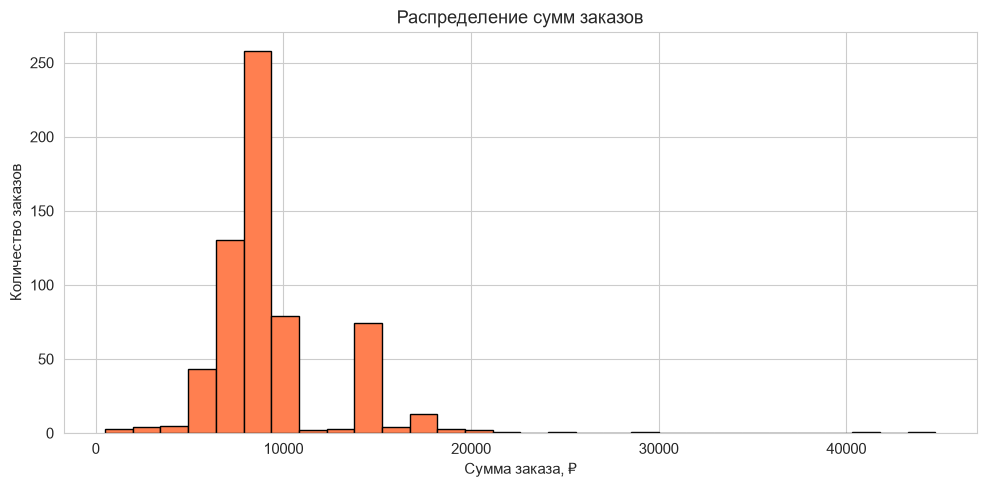

In [26]:
plt.figure(figsize=(10, 5))
plt.hist(orders['revenue'], bins=30, edgecolor='black', color='coral')
plt.title('Распределение сумм заказов')
plt.xlabel('Сумма заказа, ₽')
plt.ylabel('Количество заказов')
plt.tight_layout()
plt.show()

7. График: повторные покупки

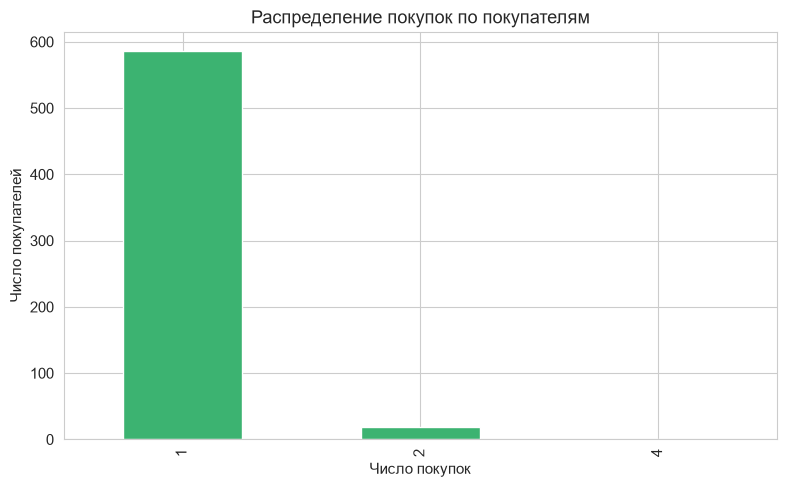

In [27]:
orders_per_user = orders.groupby('student_id').size()
repeat = orders_per_user.value_counts().sort_index()

plt.figure(figsize=(8, 5))
repeat.plot(kind='bar', color='mediumseagreen')
plt.title('Распределение покупок по покупателям')
plt.xlabel('Число покупок')
plt.ylabel('Число покупателей')
plt.tight_layout()
plt.show()

8. Аномалии: суммы

In [28]:
print("=== МАЛЕНЬКИЕ СУММЫ (< 1000) ===")
small = df[df['amount'] < 1000]
print(small[['student_id', 'amount', 'course', 'timestamp']])

print("\n=== БОЛЬШИЕ СУММЫ (> 15000) ===")
big = df[df['amount'] > 15000]
print(big[['student_id', 'amount', 'course', 'timestamp']])

=== МАЛЕНЬКИЕ СУММЫ (< 1000) ===
     student_id  amount               course           timestamp
23          477   500.0  Теория вероятностей 2026-08-06 14:52:49
134         462   500.0      Алгоритмы старт 2026-08-09 16:45:22

=== БОЛЬШИЕ СУММЫ (> 15000) ===
     student_id   amount               course           timestamp
5           480  15695.0         Data Science 2026-08-04 16:17:19
133         488  19350.0            Алгоритмы 2026-08-09 16:36:09
593         561  18900.0  Теория вероятностей 2026-09-03 18:55:28
759         509  18900.0  Теория вероятностей 2026-09-07 16:51:31


9. Аномалии: одновременные покупки

In [29]:
same_time = df.groupby('timestamp').agg(
    n_sales=('student_id', 'size'),
    n_students=('student_id', 'nunique')
).reset_index()

bursts = same_time[same_time['n_sales'] >= 3].sort_values('n_sales', ascending=False)

print(f"Всплесков (3+ покупки в секунду): {len(bursts)}")
print(bursts.head(10))

Всплесков (3+ покупки в секунду): 8
              timestamp  n_sales  n_students
624 2026-09-09 19:26:20        5           1
419 2026-09-01 18:08:01        5           1
347 2026-08-27 15:11:14        4           1
565 2026-09-06 15:18:37        4           1
222 2026-08-19 09:21:46        3           1
146 2026-08-10 16:09:27        3           1
87  2026-08-09 16:12:46        3           1
468 2026-09-04 04:51:49        3           1


10. Пакеты

In [30]:
packages = orders[orders['n_courses'] >= 2]

print(f"Пакетов: {len(packages)}")
print(f"Уникальных покупателей пакетов: {packages['student_id'].nunique()}")
print(f"Средний чек пакета: {packages['revenue'].mean():.2f} ₽")
print("\nТоп-5 пакетов:")
print(packages[['student_id', 'revenue', 'n_courses', 'courses']].head())

Пакетов: 153
Уникальных покупателей пакетов: 152
Средний чек пакета: 13849.89 ₽

Топ-5 пакетов:
    student_id  revenue  n_courses                         courses
2          102  12950.0          2               AI агенты; ML про
4          104  14950.0          2               AI агенты; ML про
6          106   9900.0          2  Backend старт; Алгоритмы старт
7          107  13950.0          2        AI агенты; Аналитика про
13         112  16950.0          2                ML про; ML старт


11. Сопоставление постов с выручкой

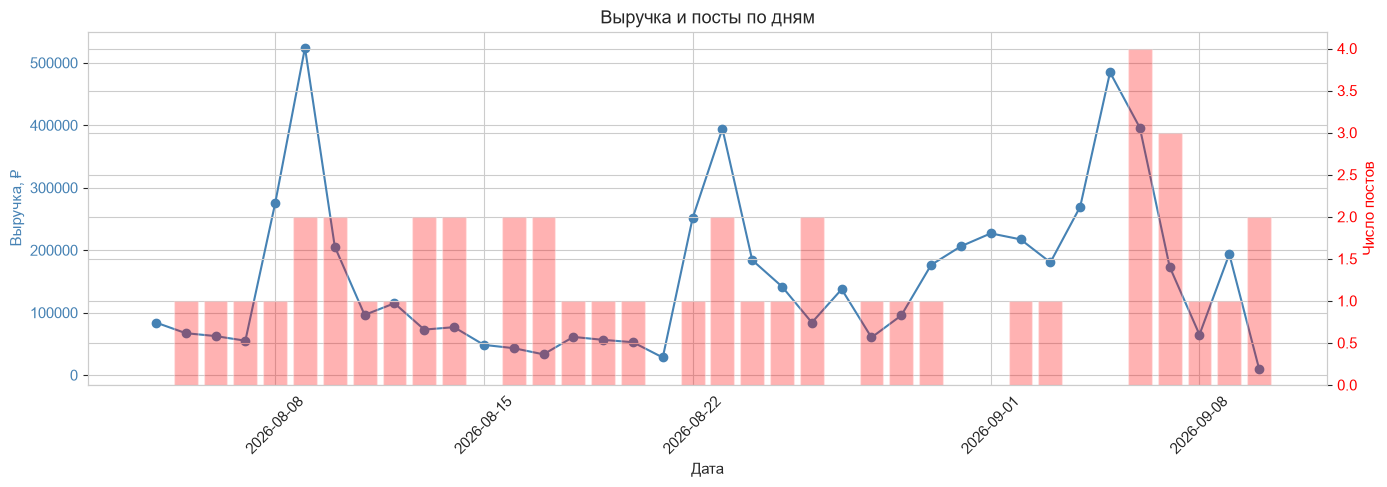

Сопоставление сохранено: 38 дней


In [31]:
BASE_DIR = Path.cwd().parent

# Загружаем посты (если уже собраны)
try:
    posts = pd.read_csv(BASE_DIR / 'data' / 'posts_classified.csv')
    posts['date'] = pd.to_datetime(posts['date']).dt.date
    
    # Группируем посты по дате
    posts_by_date = posts.groupby('date').size().reset_index(name='n_posts')
    
    # Объединяем с daily
    match = daily.merge(posts_by_date, on='date', how='left')
    match['n_posts'] = match['n_posts'].fillna(0)
    
    # График: выручка + посты
    fig, ax1 = plt.subplots(figsize=(14, 5))
    
    ax1.plot(match['date'], match['revenue'], color='steelblue', marker='o', label='Выручка')
    ax1.set_xlabel('Дата')
    ax1.set_ylabel('Выручка, ₽', color='steelblue')
    ax1.tick_params(axis='y', labelcolor='steelblue')
    plt.xticks(rotation=45)
    
    ax2 = ax1.twinx()
    ax2.bar(match['date'], match['n_posts'], alpha=0.3, color='red', label='Посты')
    ax2.set_ylabel('Число постов', color='red')
    ax2.tick_params(axis='y', labelcolor='red')
    
    plt.title('Выручка и посты по дням')
    plt.tight_layout()
    plt.savefig(BASE_DIR / 'docs' / 'figures' / 'posts_vs_revenue.png', dpi=150)
    plt.show()
    
    match.to_csv(BASE_DIR / 'data' / 'posts_vs_revenue.csv', index=False)
    print(f"Сопоставление сохранено: {len(match)} дней")
    
except FileNotFoundError:
    print("posts.csv пока нет — собери посты и запусти снова")

12. Выводы 

In [32]:
print("=" * 50)
print("КЛЮЧЕВЫЕ ВЫВОДЫ")
print("=" * 50)

print(f"\n1. Масштаб:")
print(f"   - {len(df)} строк продаж")
print(f"   - {df['student_id'].nunique()} покупателей")
print(f"   - {len(orders)} заказов")
print(f"   - {df['course'].nunique()} курсов")

print(f"\n2. Повторные покупки:")
n_repeat = (orders.groupby('student_id').size() >= 2).sum()
print(f"   - {n_repeat} покупателей купили 2+ раз ({n_repeat / df['student_id'].nunique() * 100:.1f}%)")

print(f"\n3. Пакеты:")
print(f"   - {len(packages)} заказов с 2+ курсами")
print(f"   - Средний чек пакета: {packages['revenue'].mean():.2f} ₽")

print(f"\n4. Аномалии:")
print(f"   - Суммы < 1000: {len(small)}")
print(f"   - Суммы > 15000: {len(big)}")
print(f"   - Всплесков (3+ в секунду): {len(bursts)}")

print(f"\n5. Динамика:")
print(f"   - Лучший день: {daily.loc[daily['revenue'].idxmax(), 'date']}")
print(f"   - Максимум выручки: {daily['revenue'].max():.2f} ₽")
print(f"   - Общая выручка: {daily['revenue'].sum():.2f} ₽")

КЛЮЧЕВЫЕ ВЫВОДЫ

1. Масштаб:
   - 795 строк продаж
   - 606 покупателей
   - 628 заказов
   - 18 курсов

2. Повторные покупки:
   - 20 покупателей купили 2+ раз (3.3%)

3. Пакеты:
   - 153 заказов с 2+ курсами
   - Средний чек пакета: 13849.89 ₽

4. Аномалии:
   - Суммы < 1000: 2
   - Суммы > 15000: 4
   - Всплесков (3+ в секунду): 8

5. Динамика:
   - Лучший день: 2026-08-09
   - Максимум выручки: 524091.67 ₽
   - Общая выручка: 5904671.67 ₽
